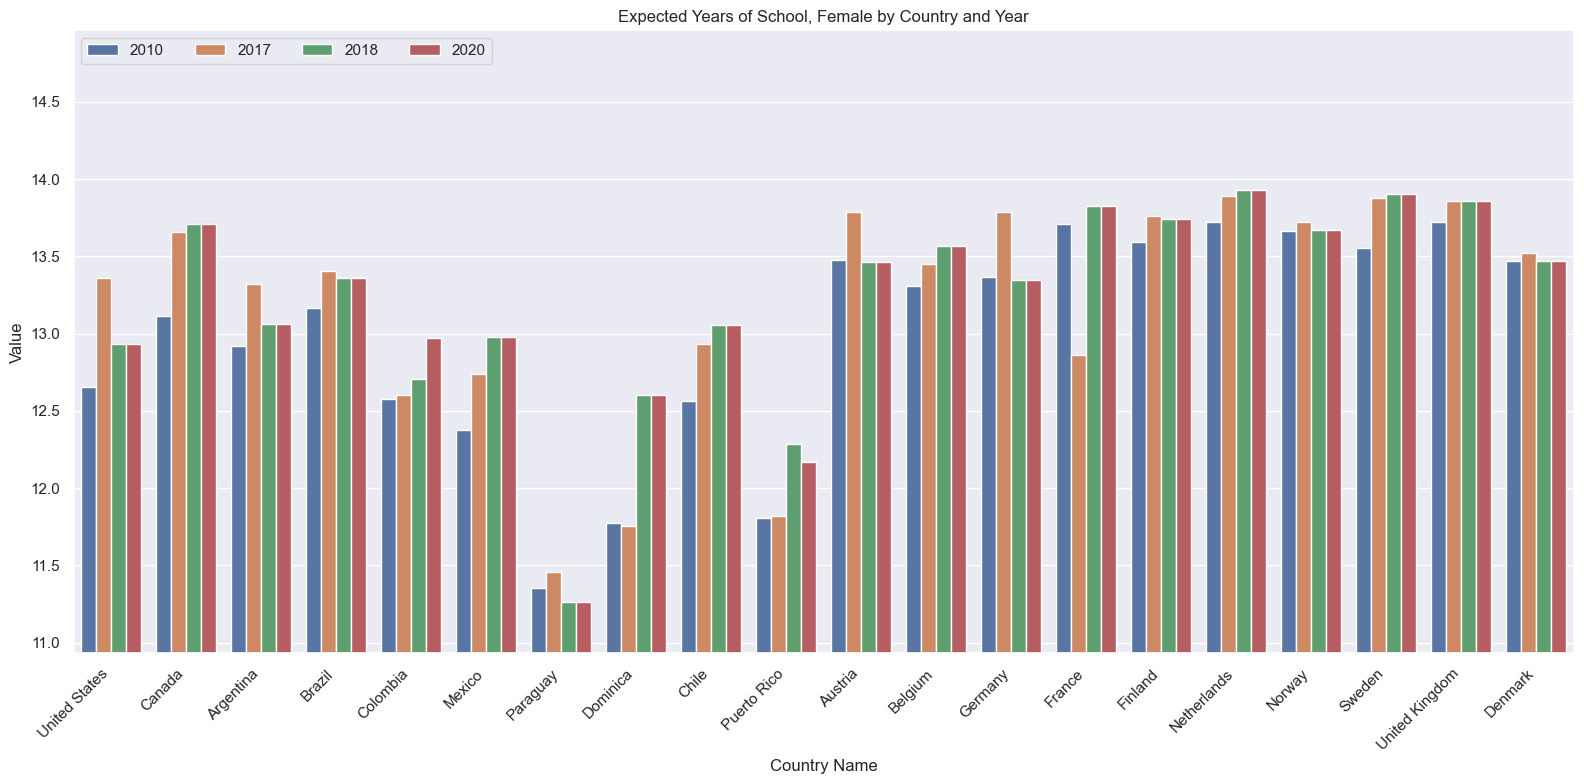

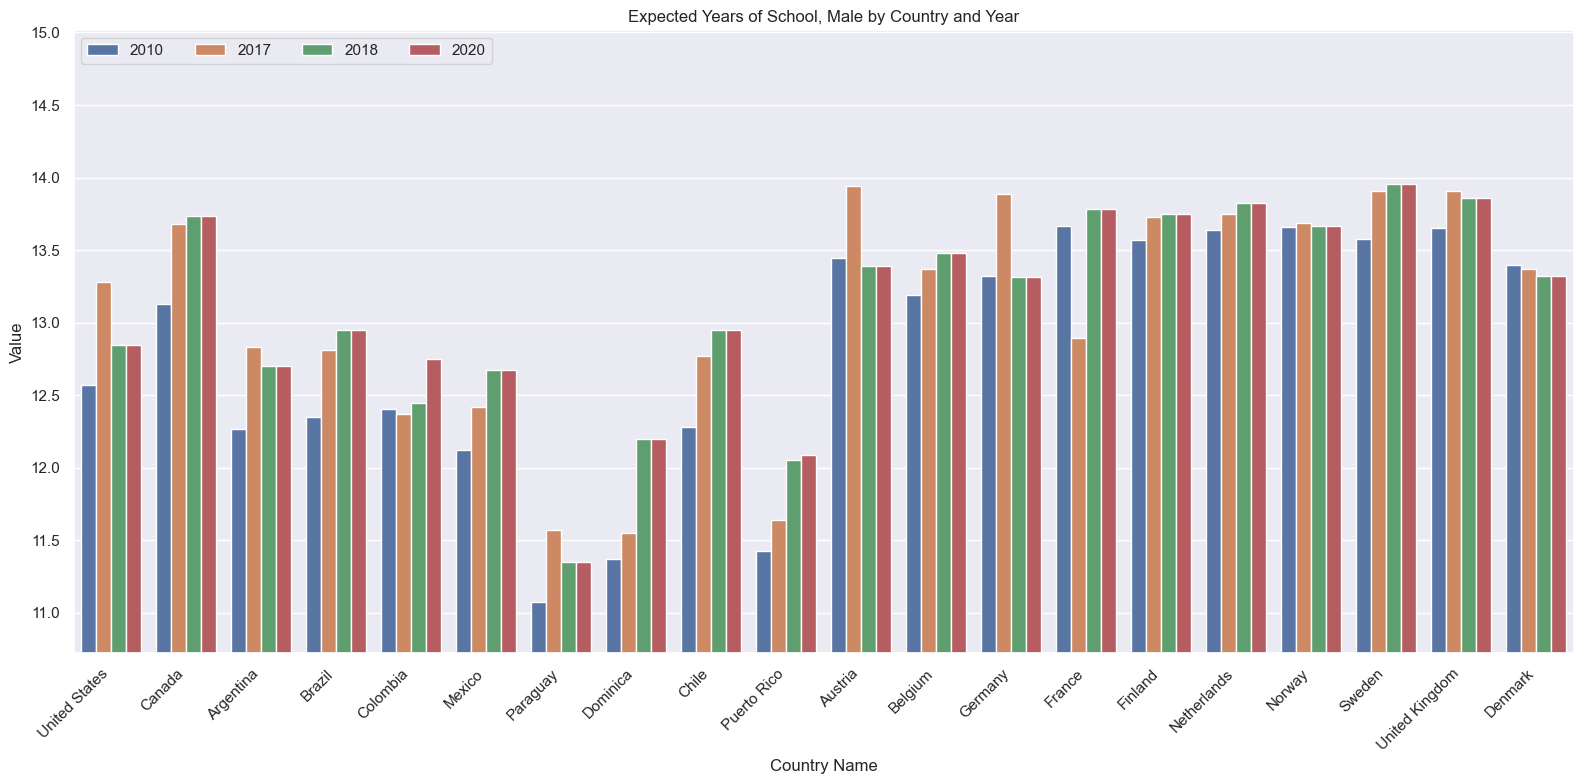

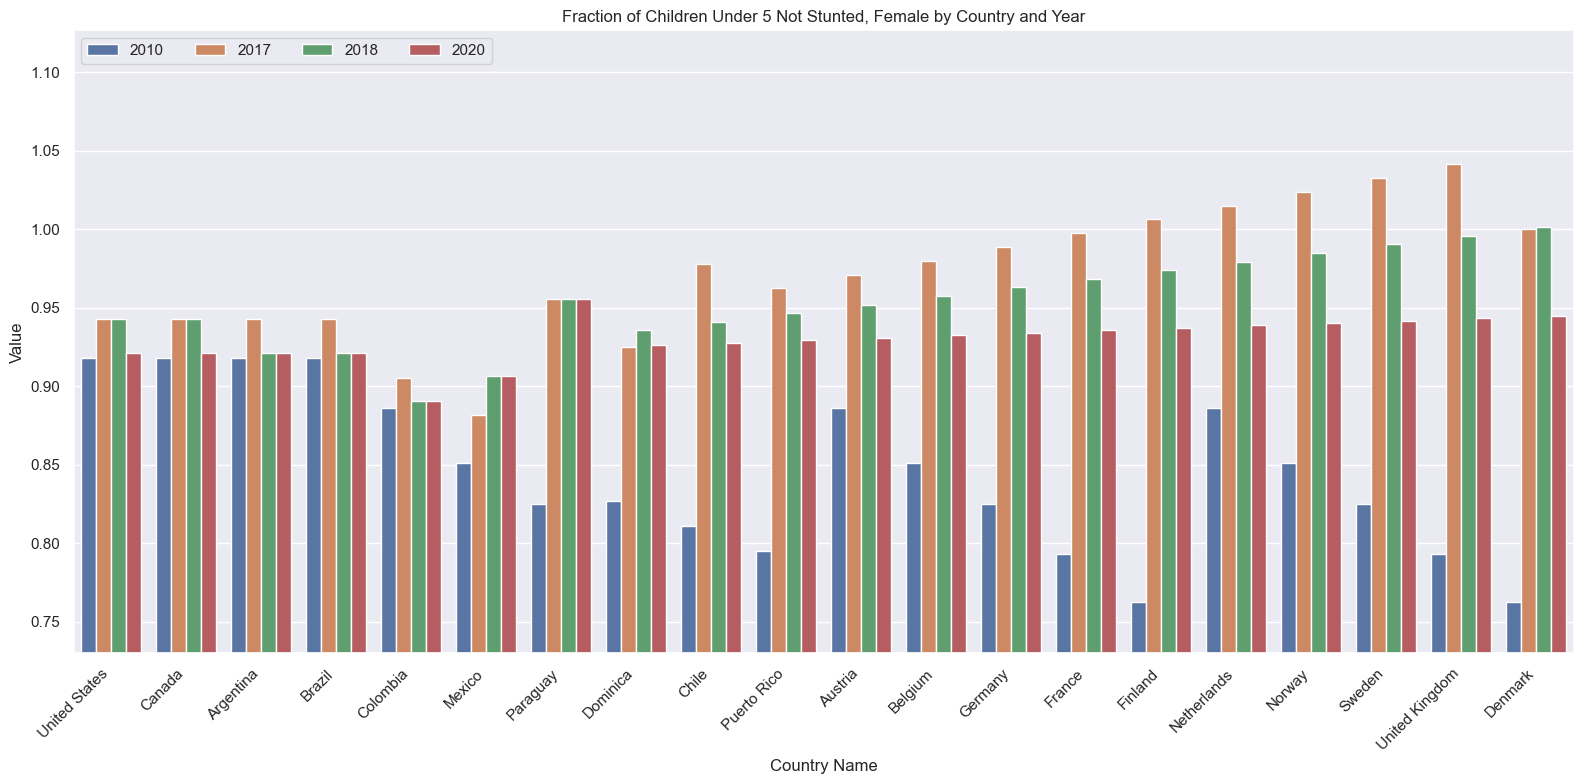

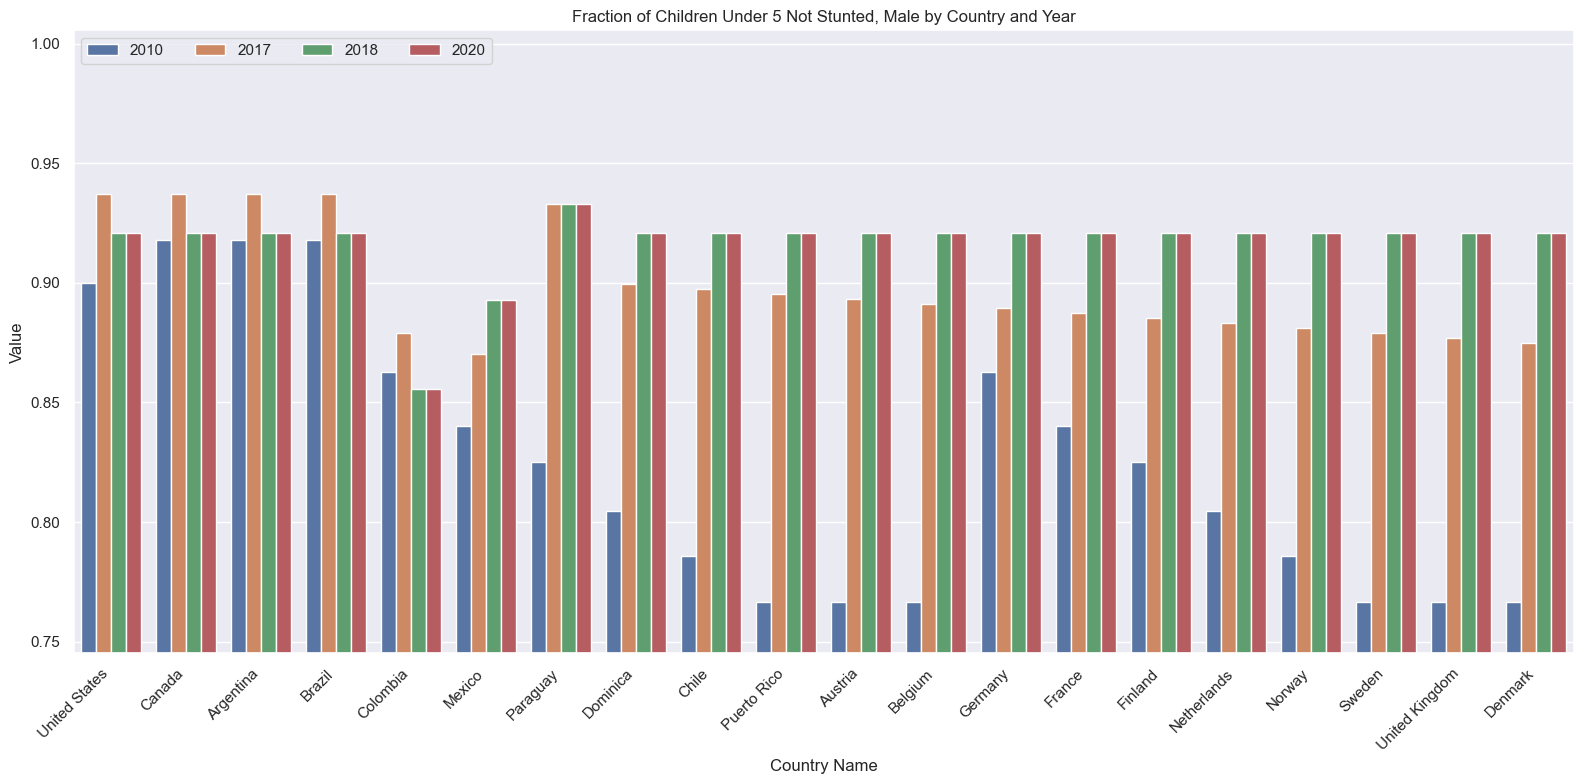

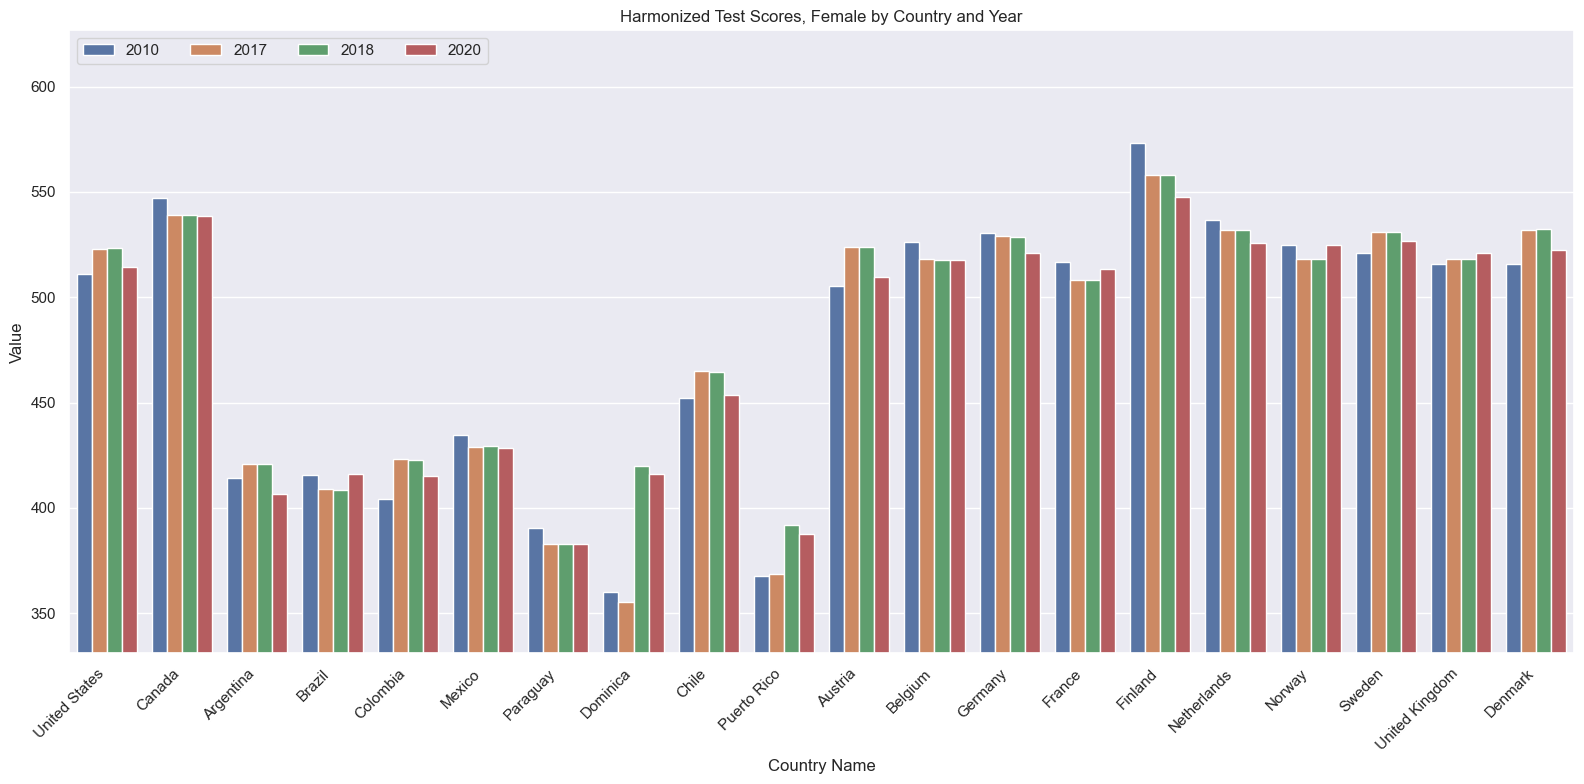

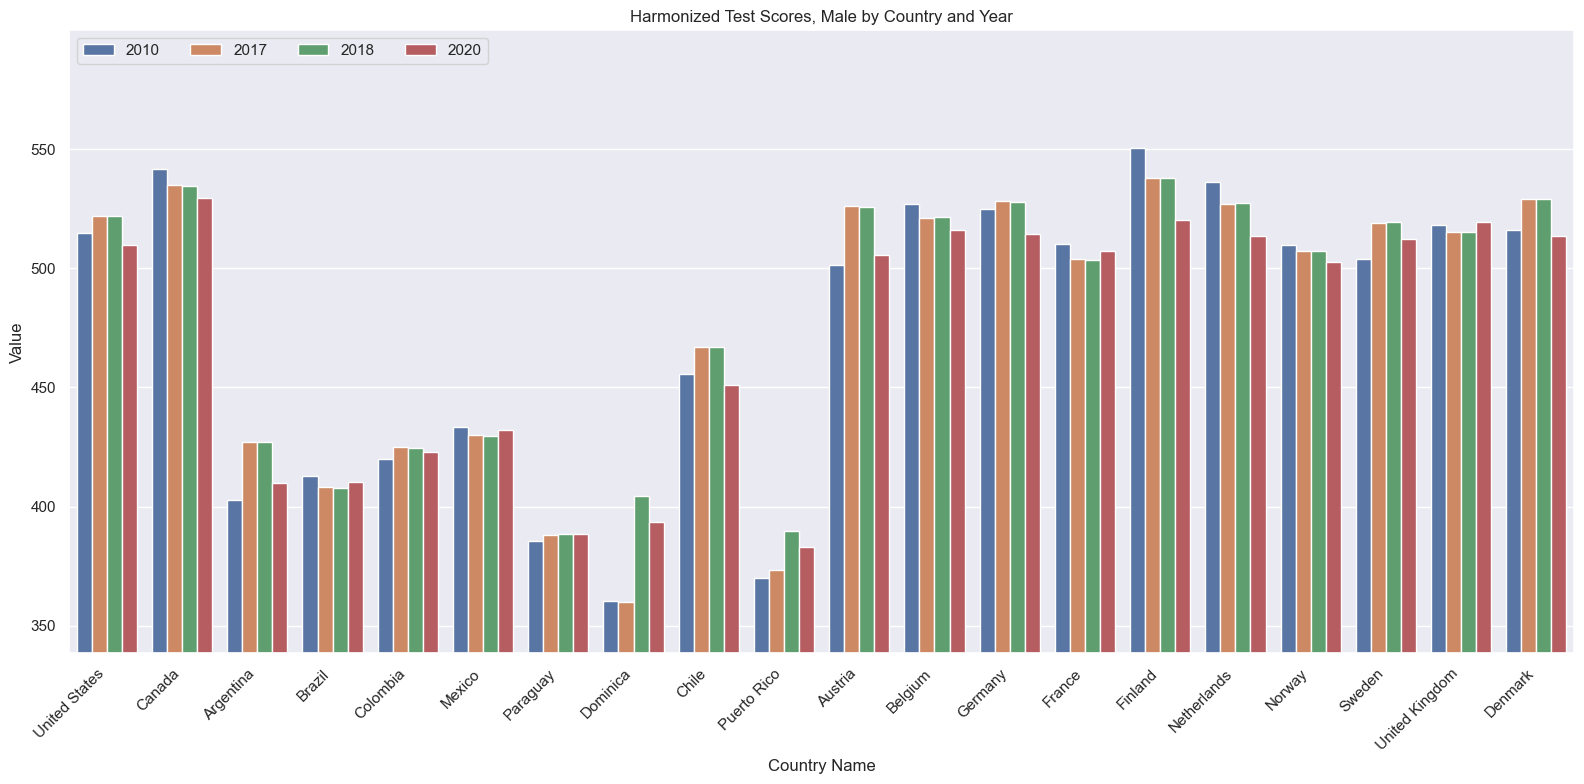

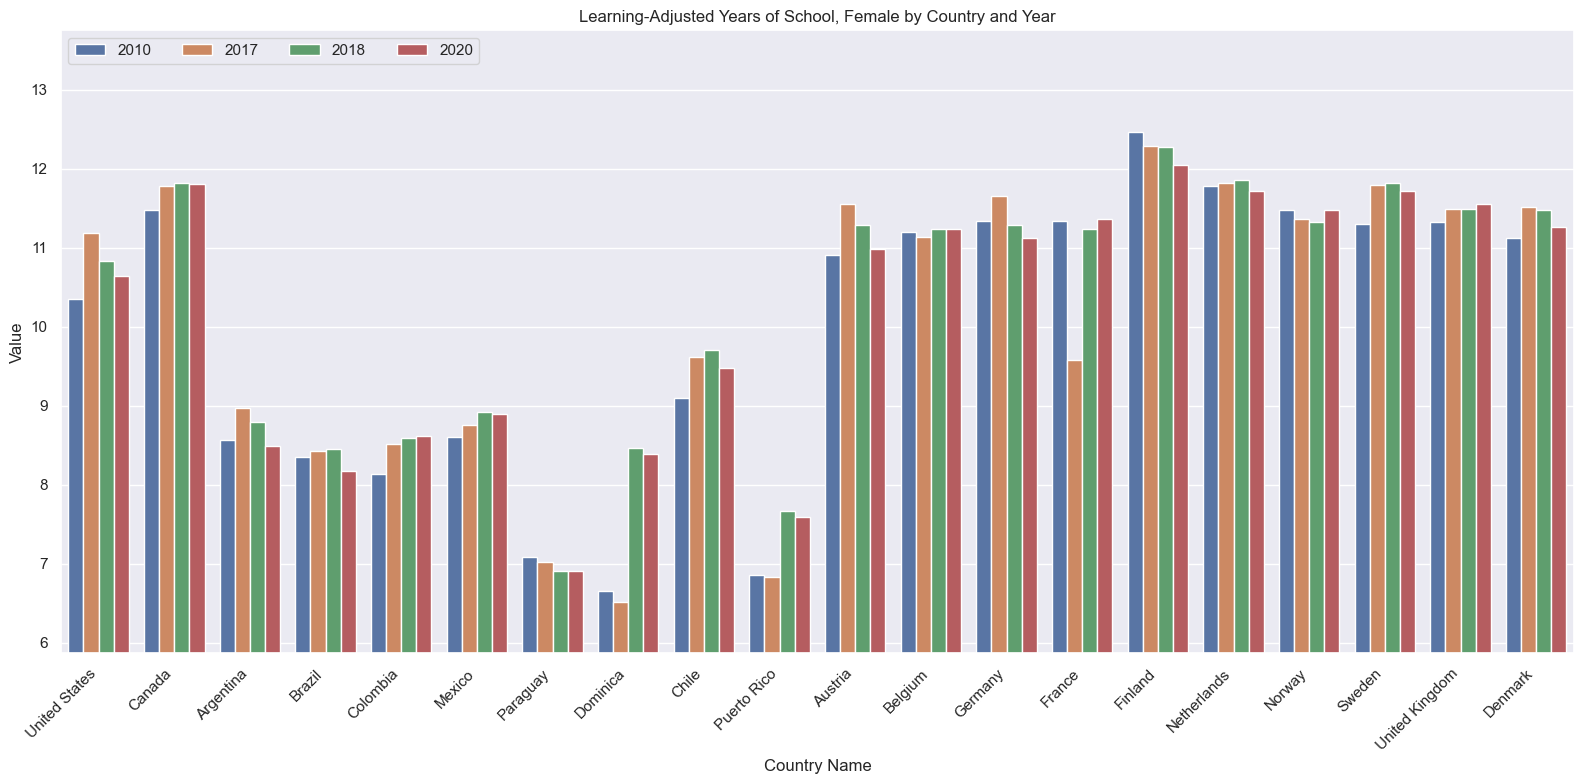

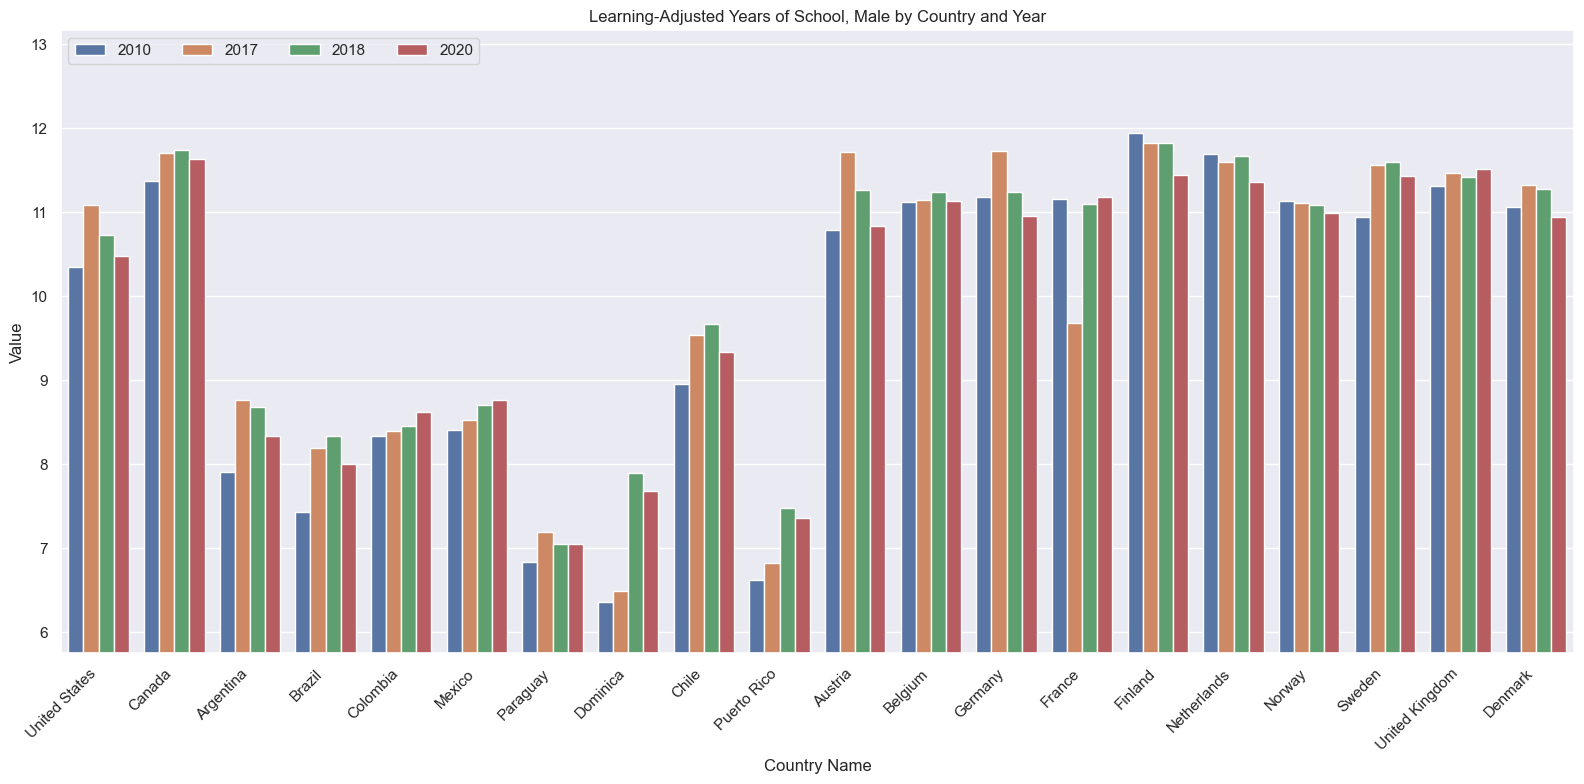

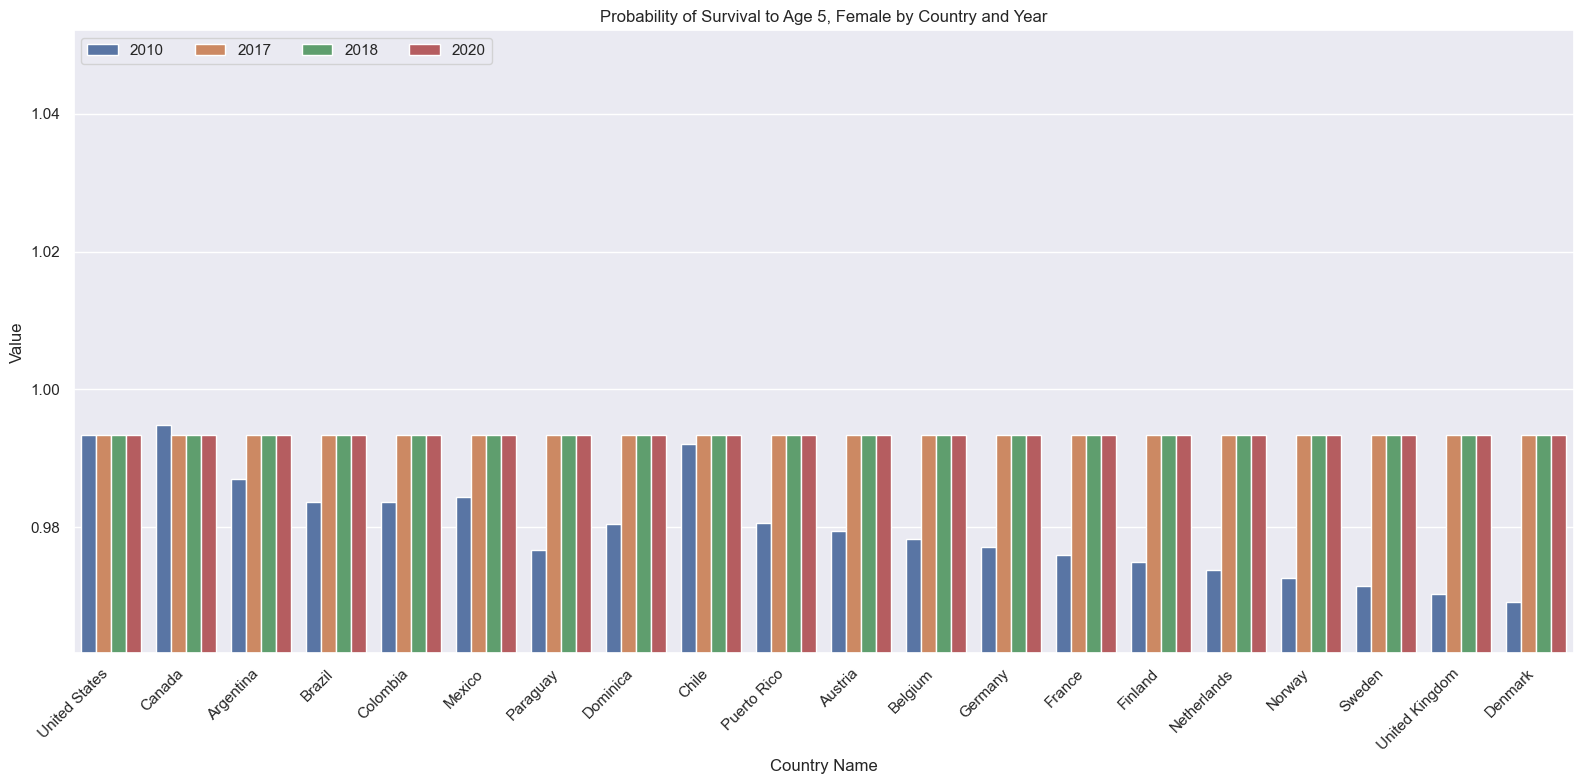

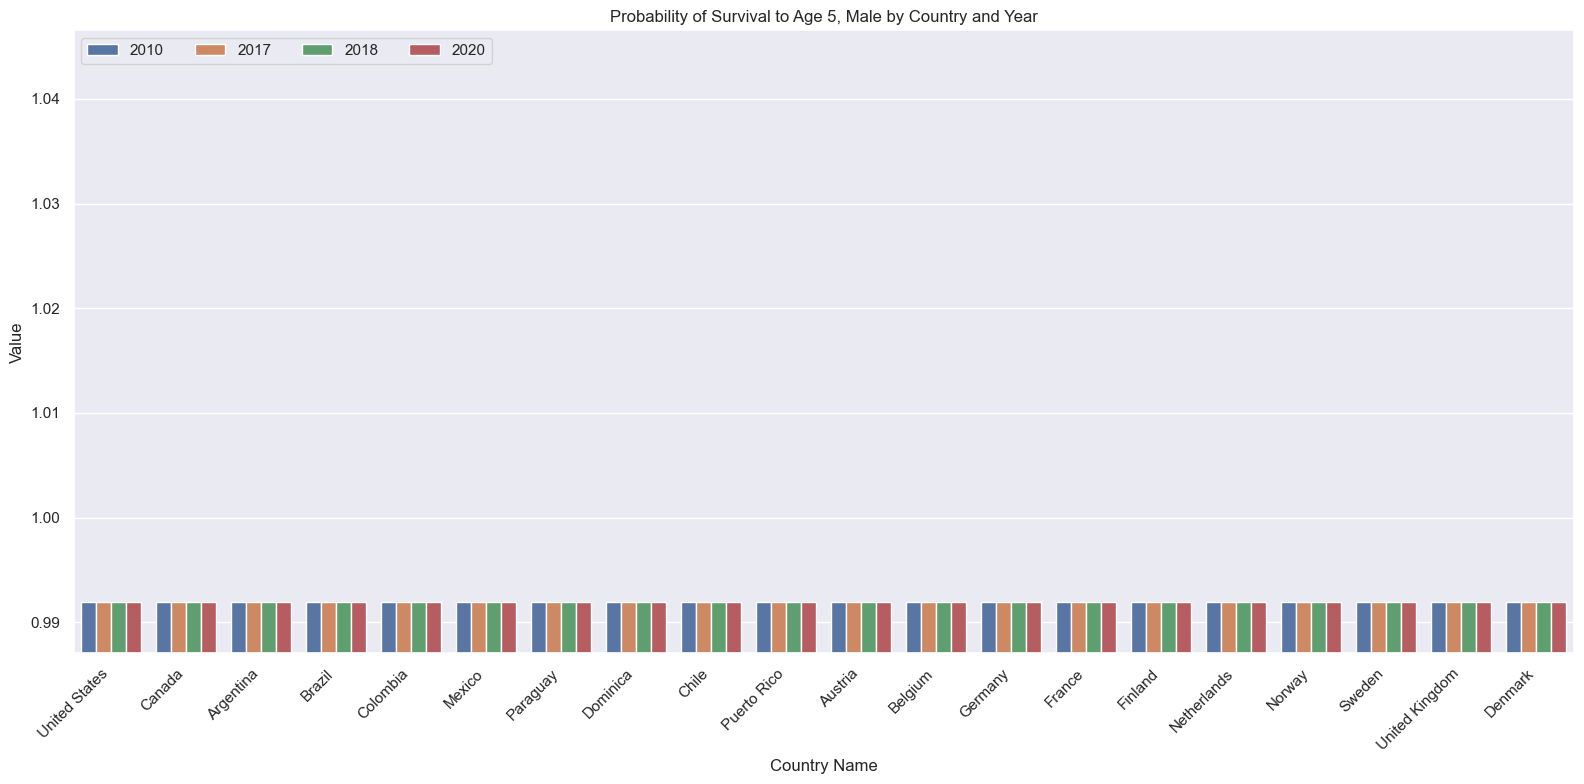

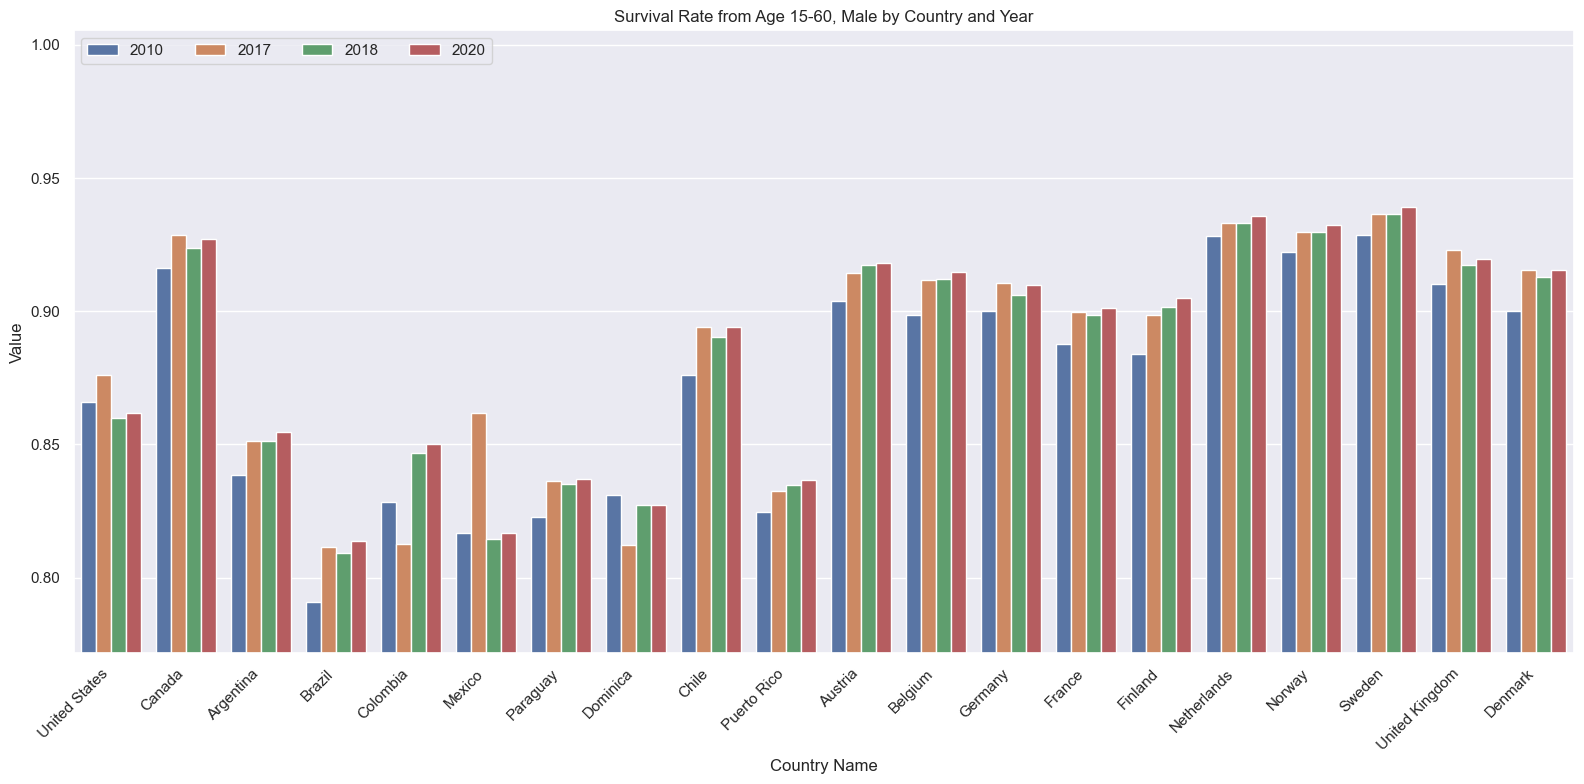

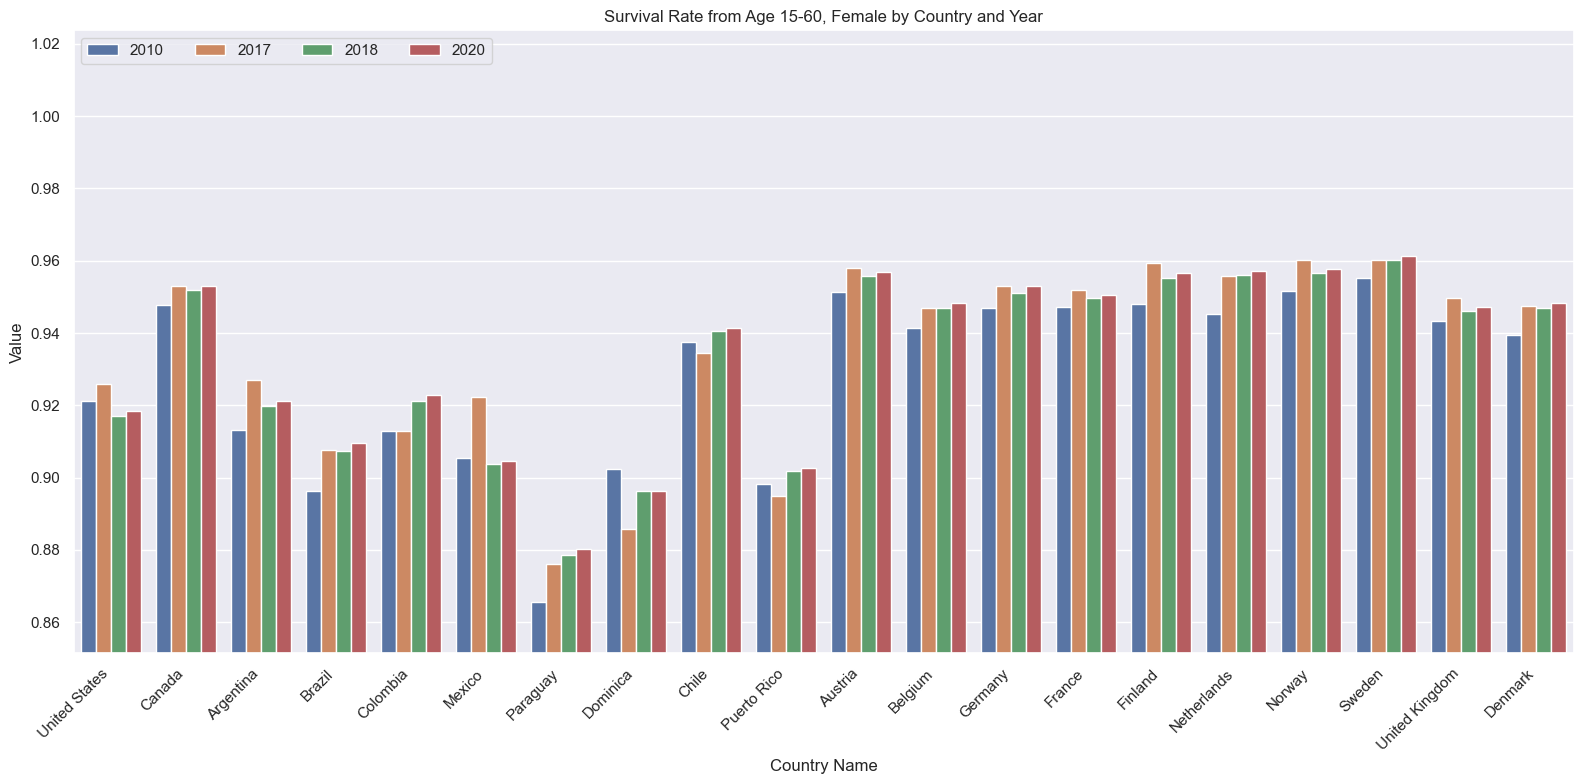

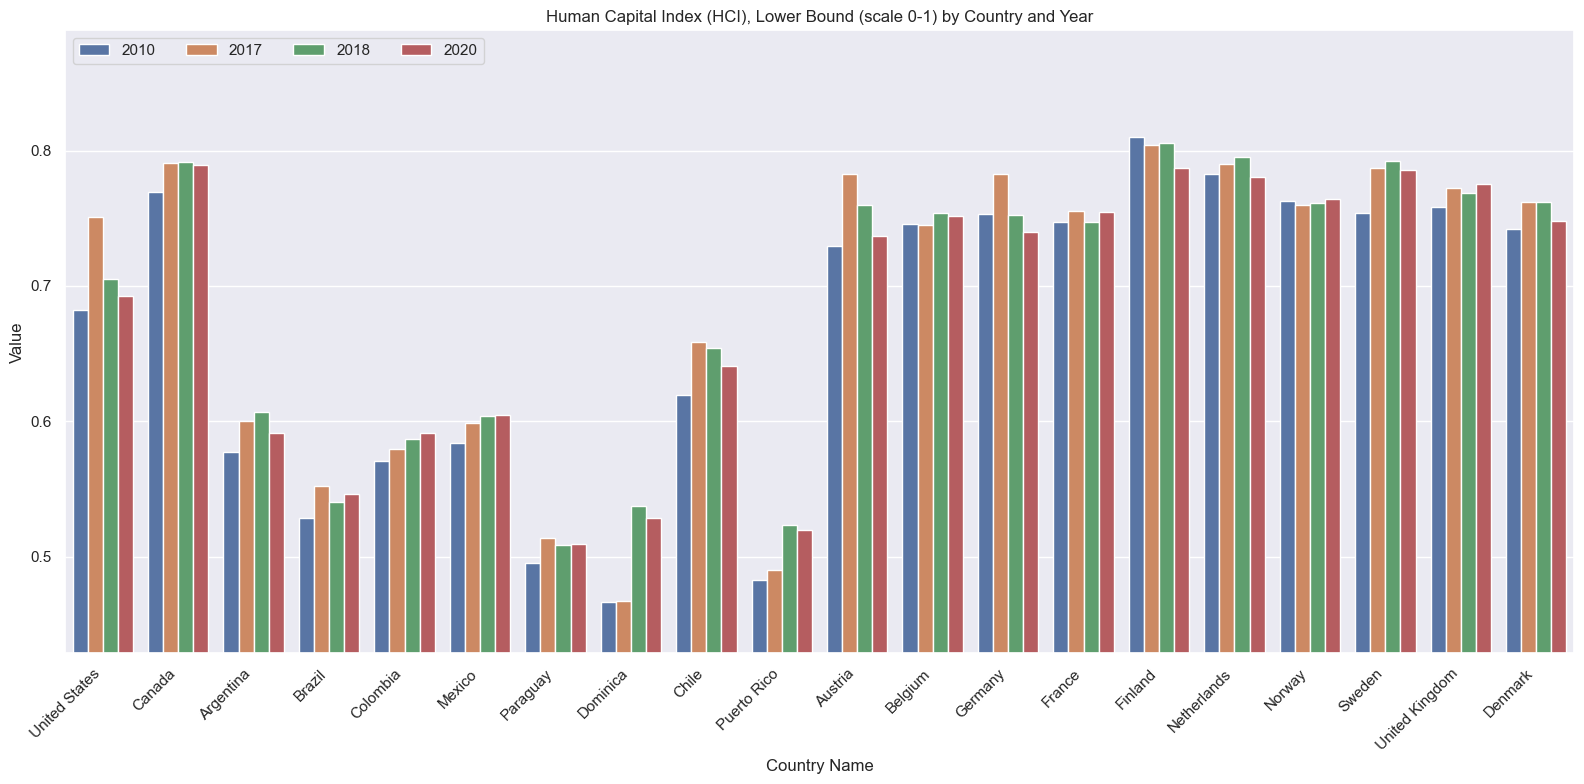

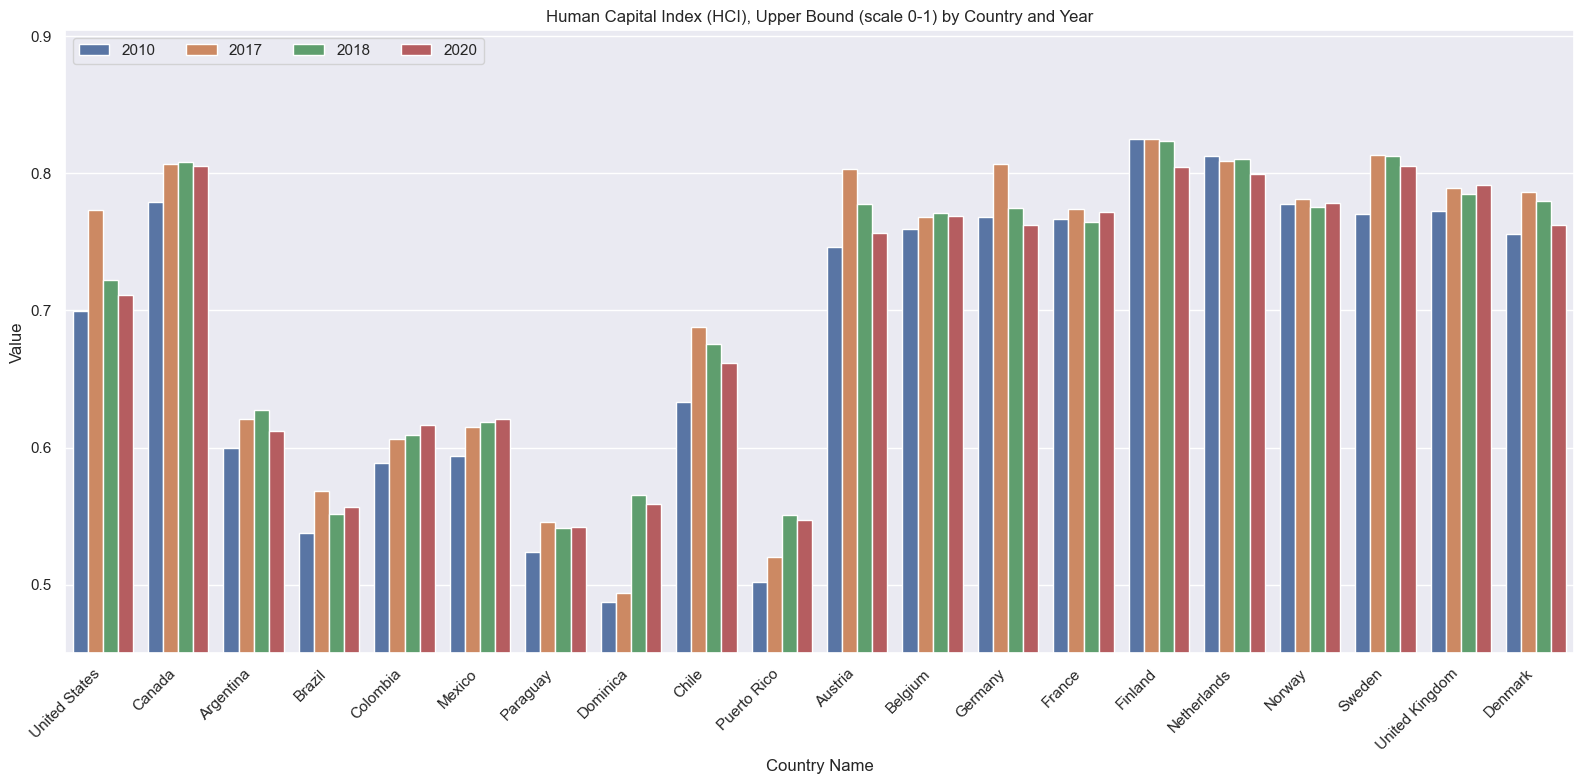

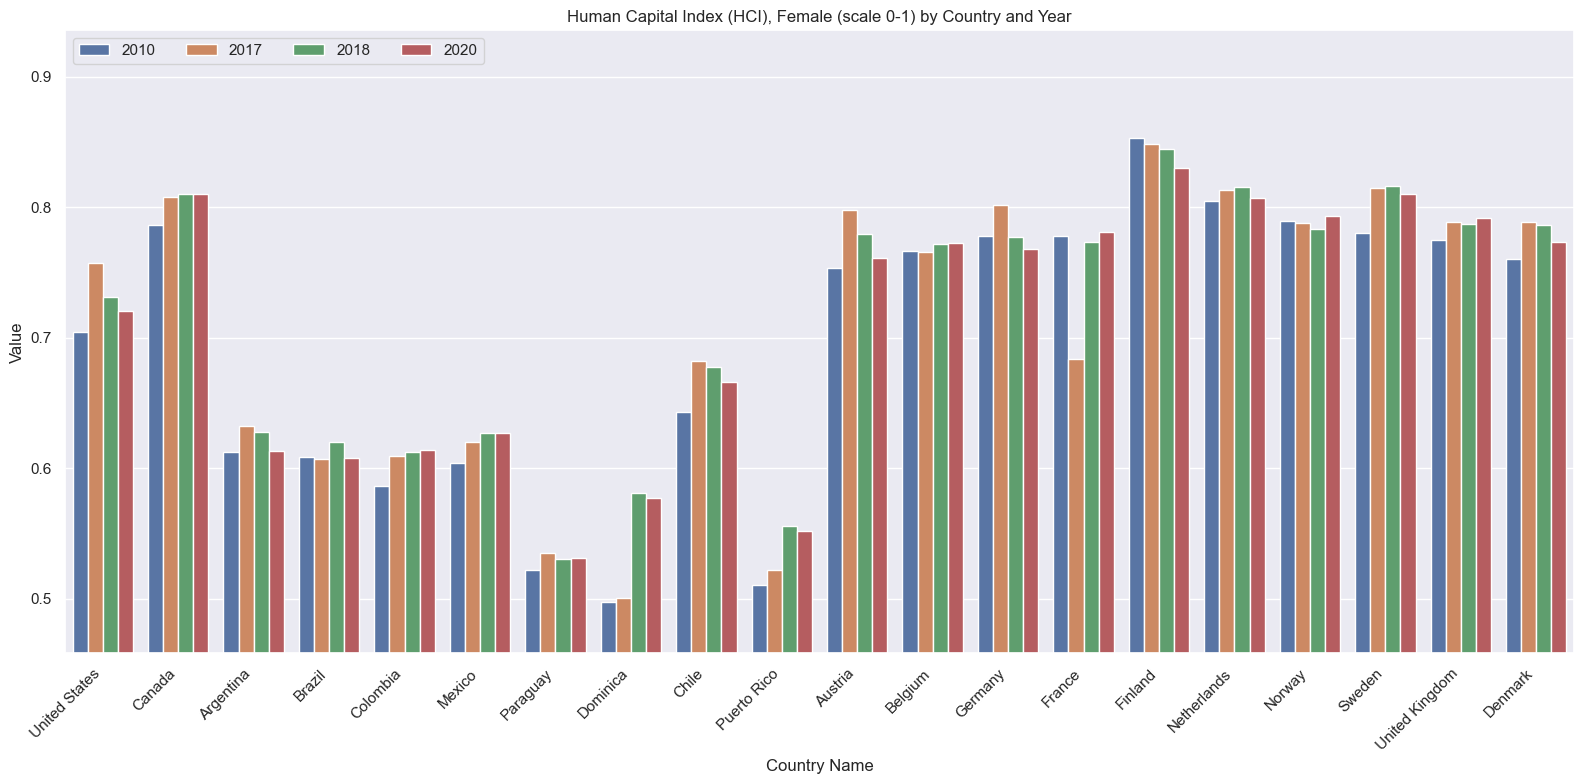

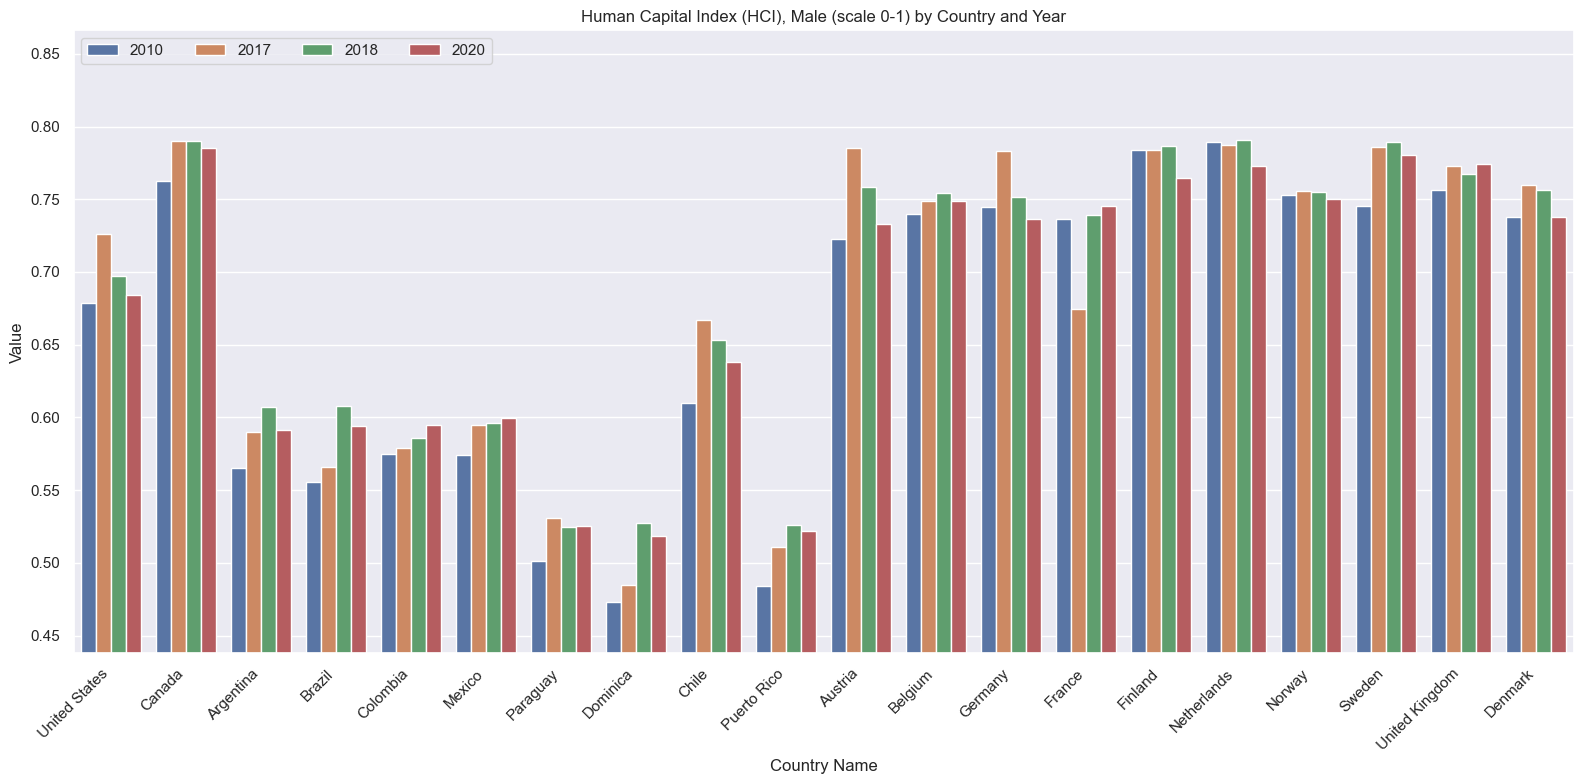

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Load the Excel file
file_path = "P_Data_Extract_From_Human_Capital_Index-one (Edited).xlsm"  # Update this path as needed
df = pd.read_excel(file_path, sheet_name='Data')

# Choose the indicator to analyze
for selected_series in df["Series Name"].unique():
    filtered_df = df[df["Series Name"] == selected_series]
    
    # Define the years to use
    years = ["2010", "2017", "2018", "2020"]
    
    # Reshape the data to long format
    plot_df = filtered_df.melt(id_vars=["Country Name"], value_vars=years,
                               var_name="Year", value_name="Value")
    min_value = plot_df["Value"].min()

    
    # Create the bar plot
    plt.figure(figsize=(16, 8))
    sns.barplot(data=plot_df, x="Country Name", y="Value", hue="Year")
    
    # Customize plot
    plt.title(f'{selected_series} by Country and Year')
    xmin, xmax, ymin, ymax = plt.axis()
    #print(ymin, ymax)
    plt.axis([xmin, xmax, min_value-(ymax-min_value)/10, ymax+(ymax-min_value)/10])
    plt.ylabel("Value")
    #plt.yscale("linear")
    plt.xticks(rotation=45, ha="right")
    plt.legend(loc="upper left", ncols=7)
    plt.tight_layout()
    plt.grid(True, axis='y')
    
    plt.show()


In [5]:
s = (8.5633211/14) * 0.9870527 * (0.918+0.9131067)/2
print(s)

0.5527620137437473


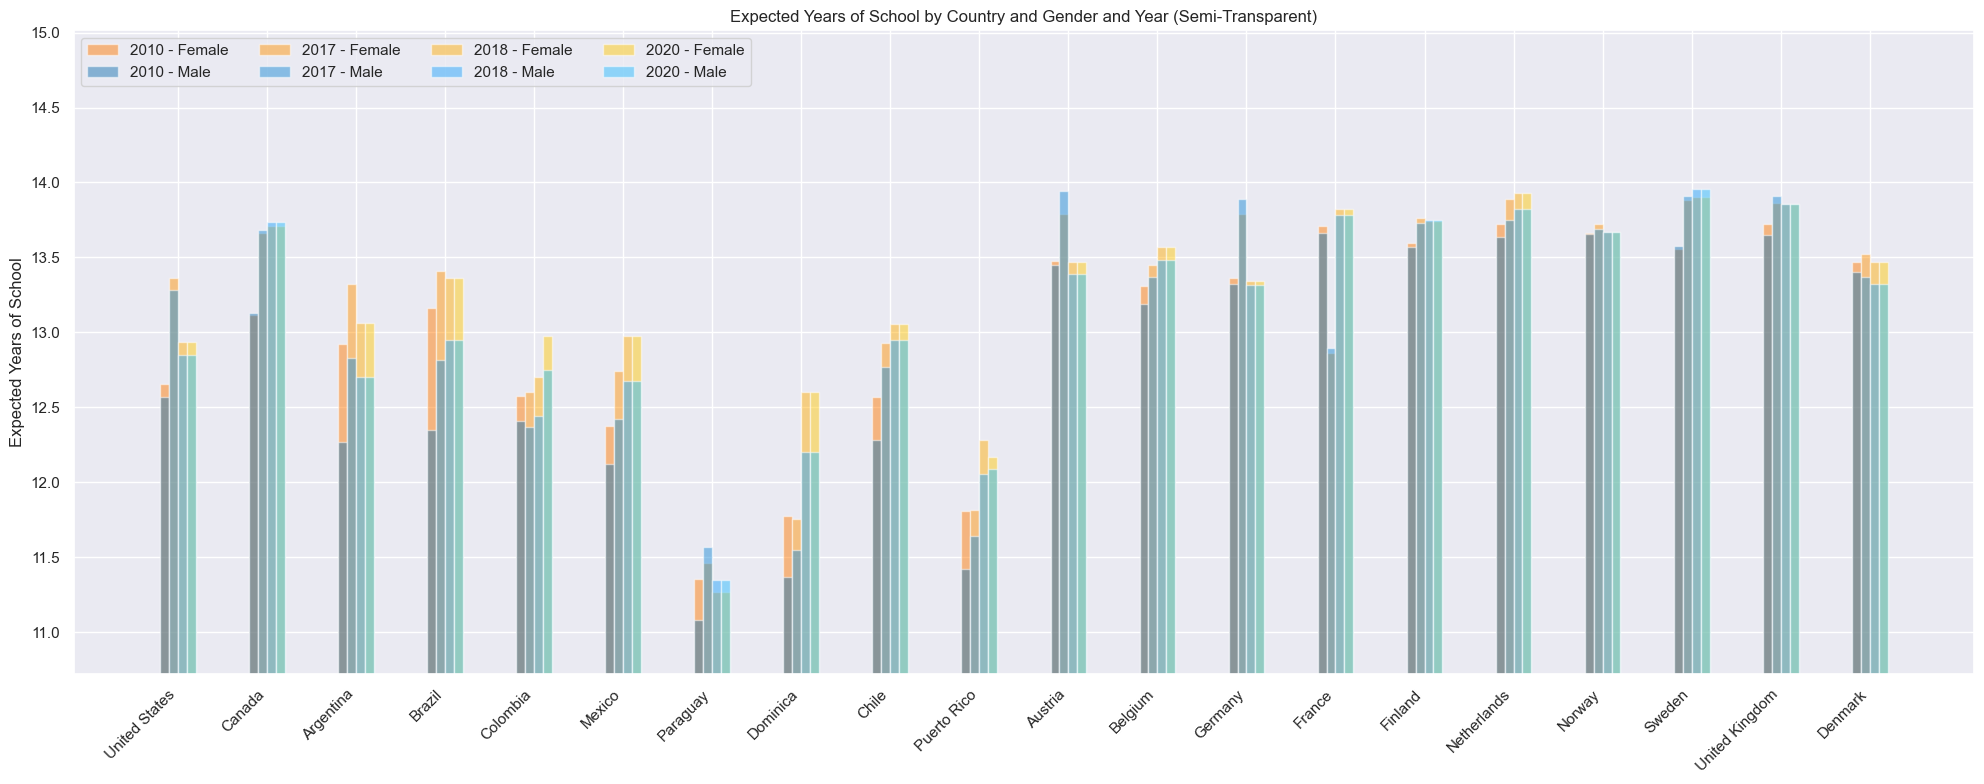

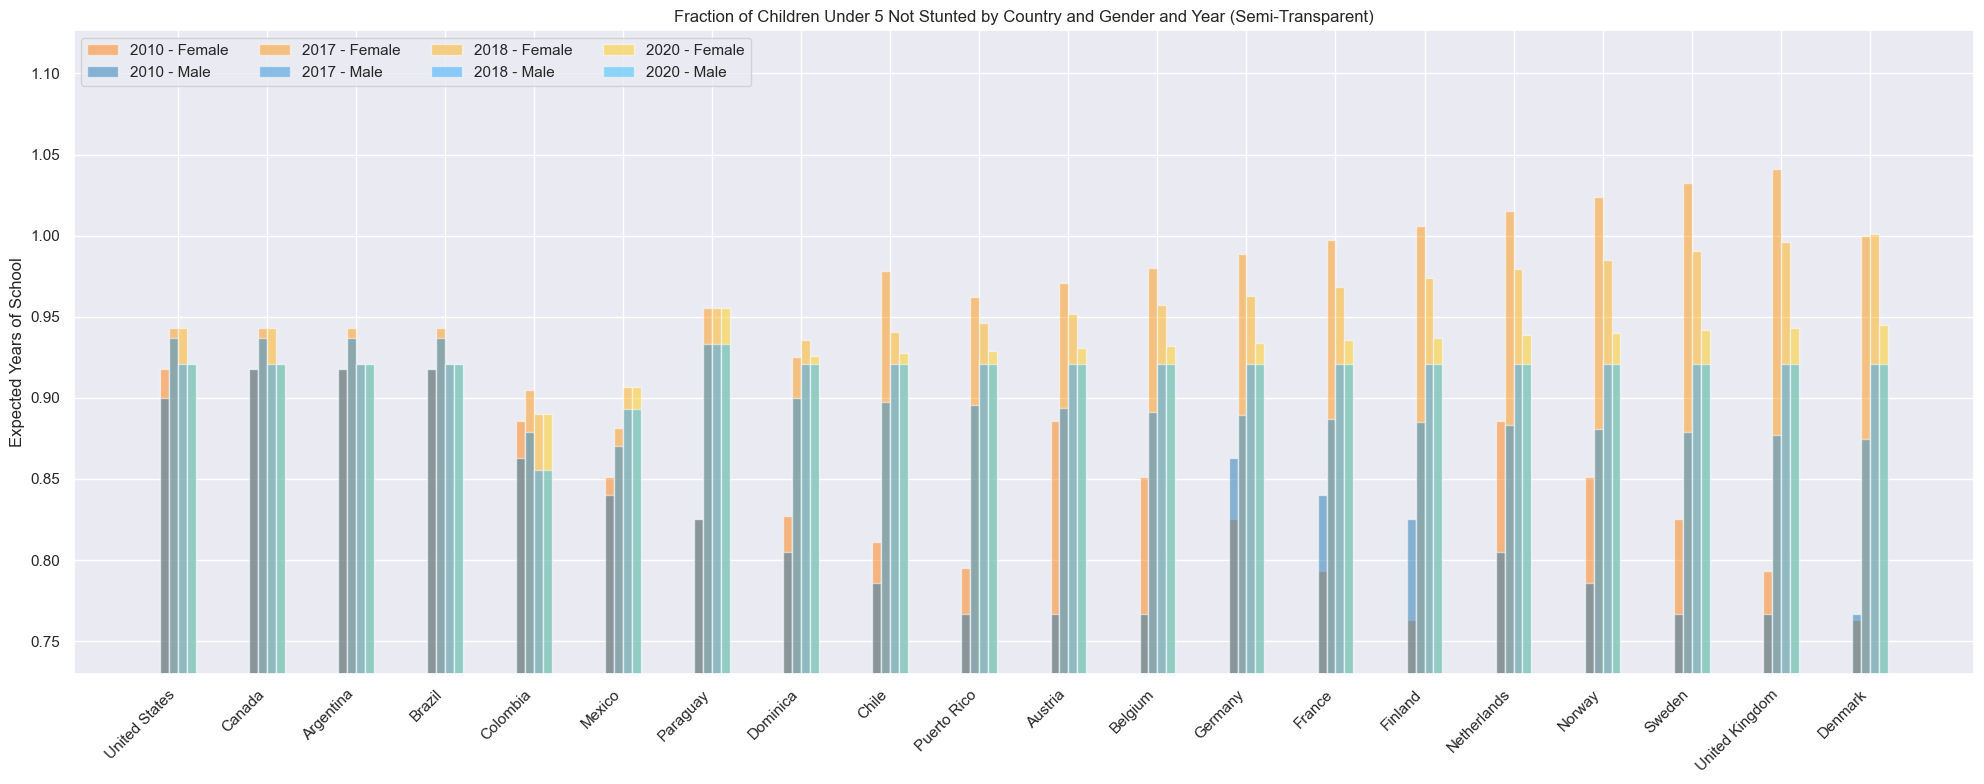

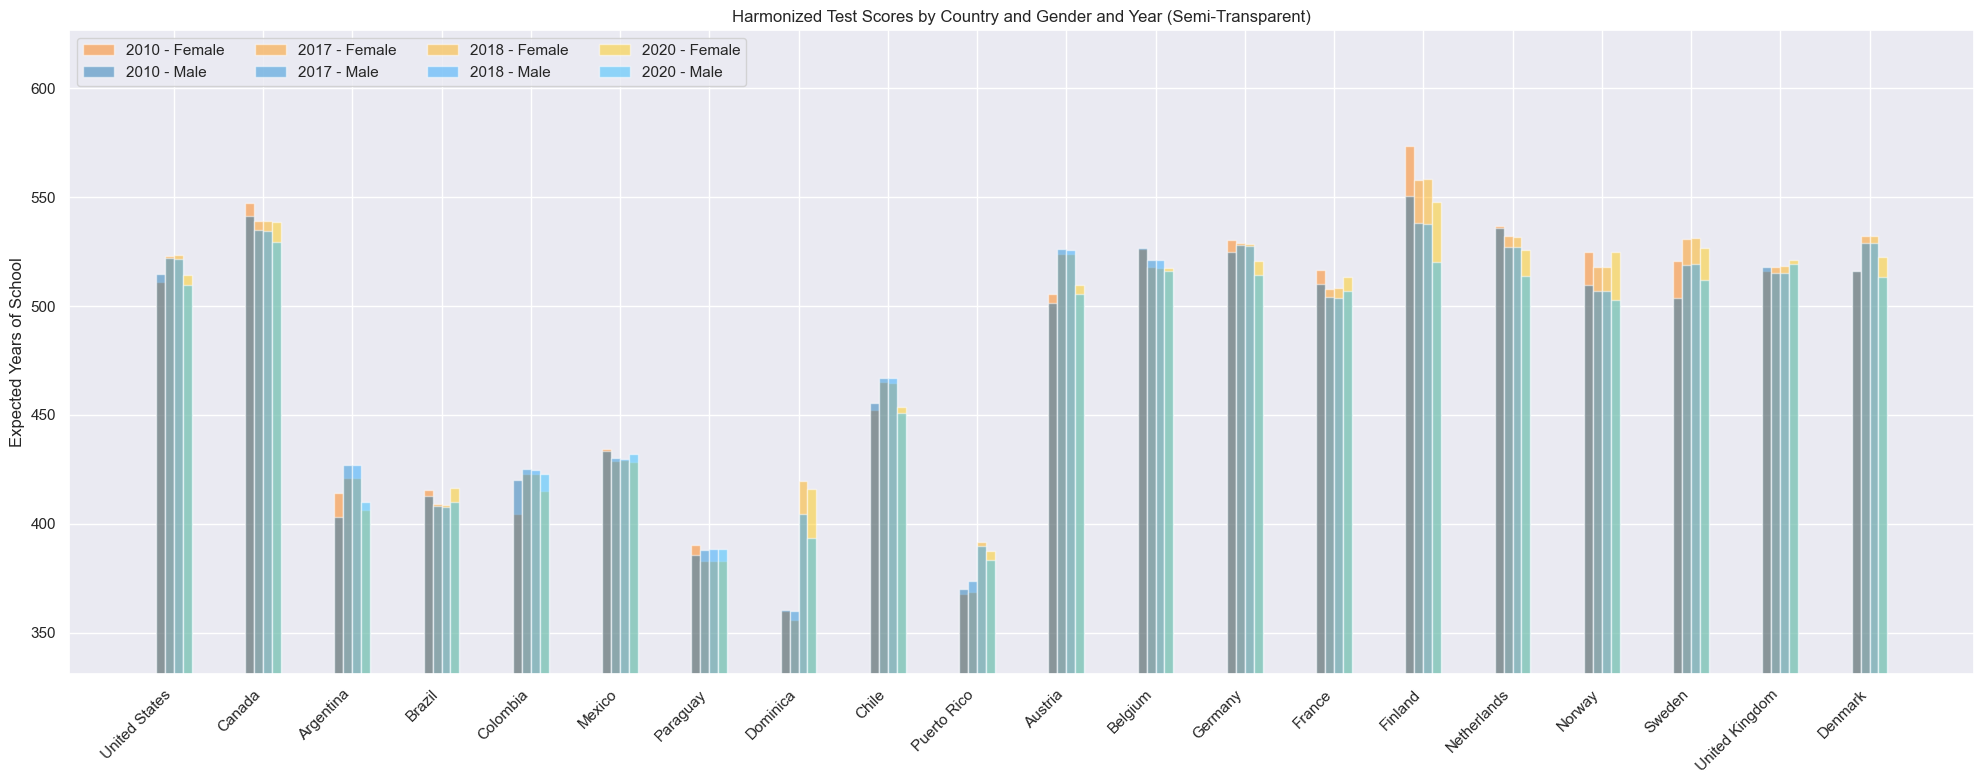

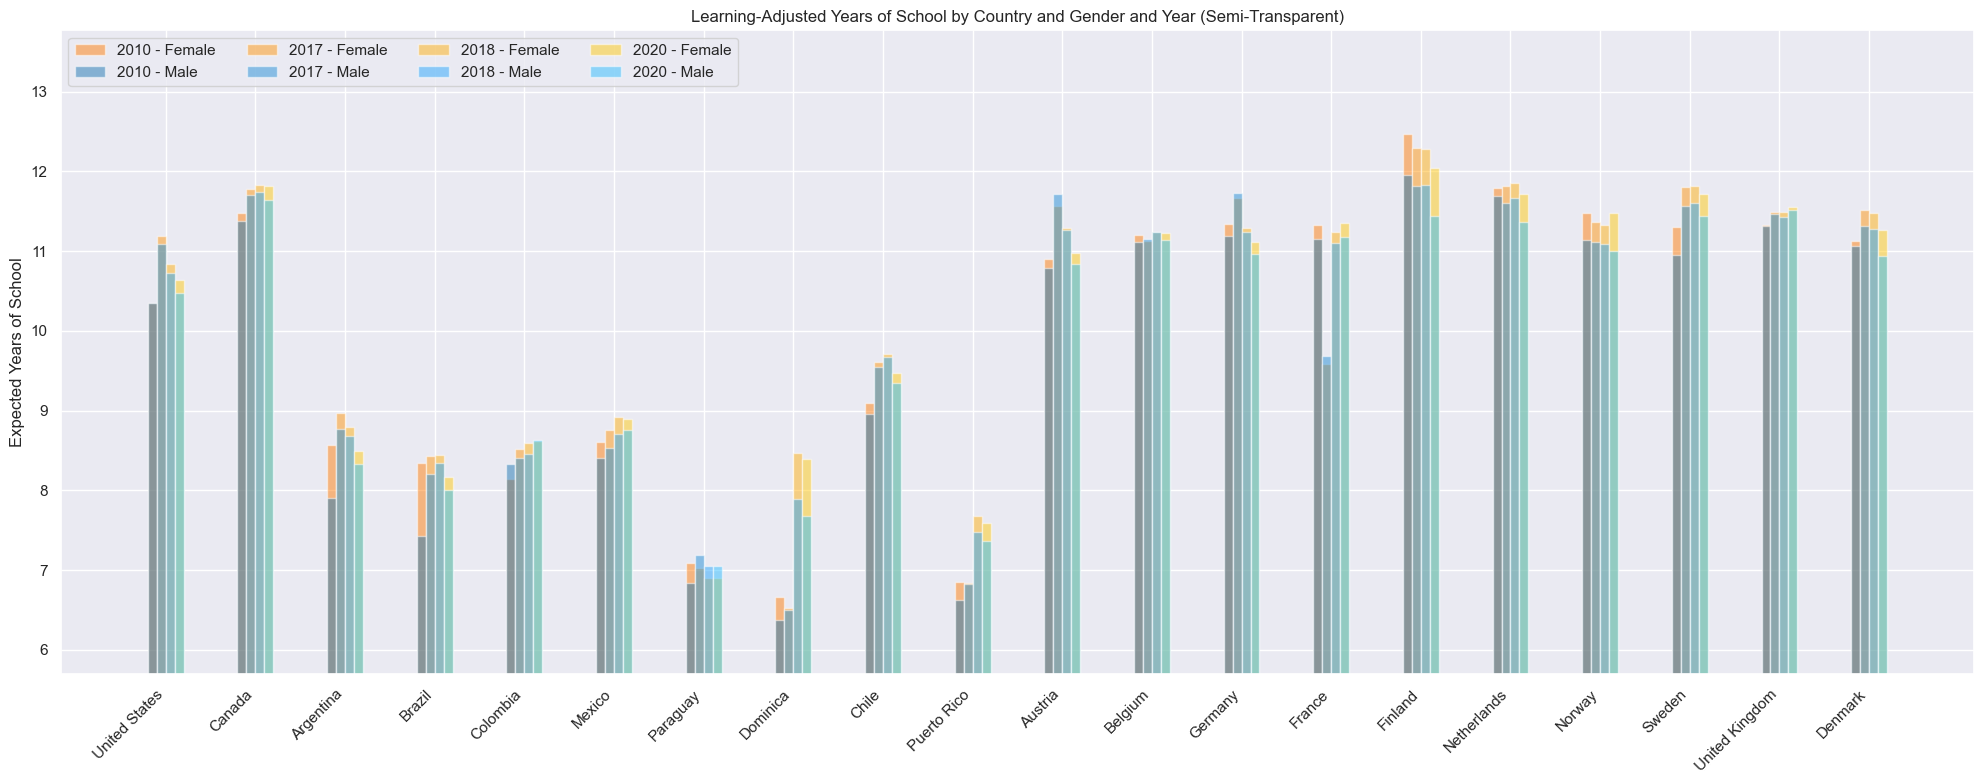

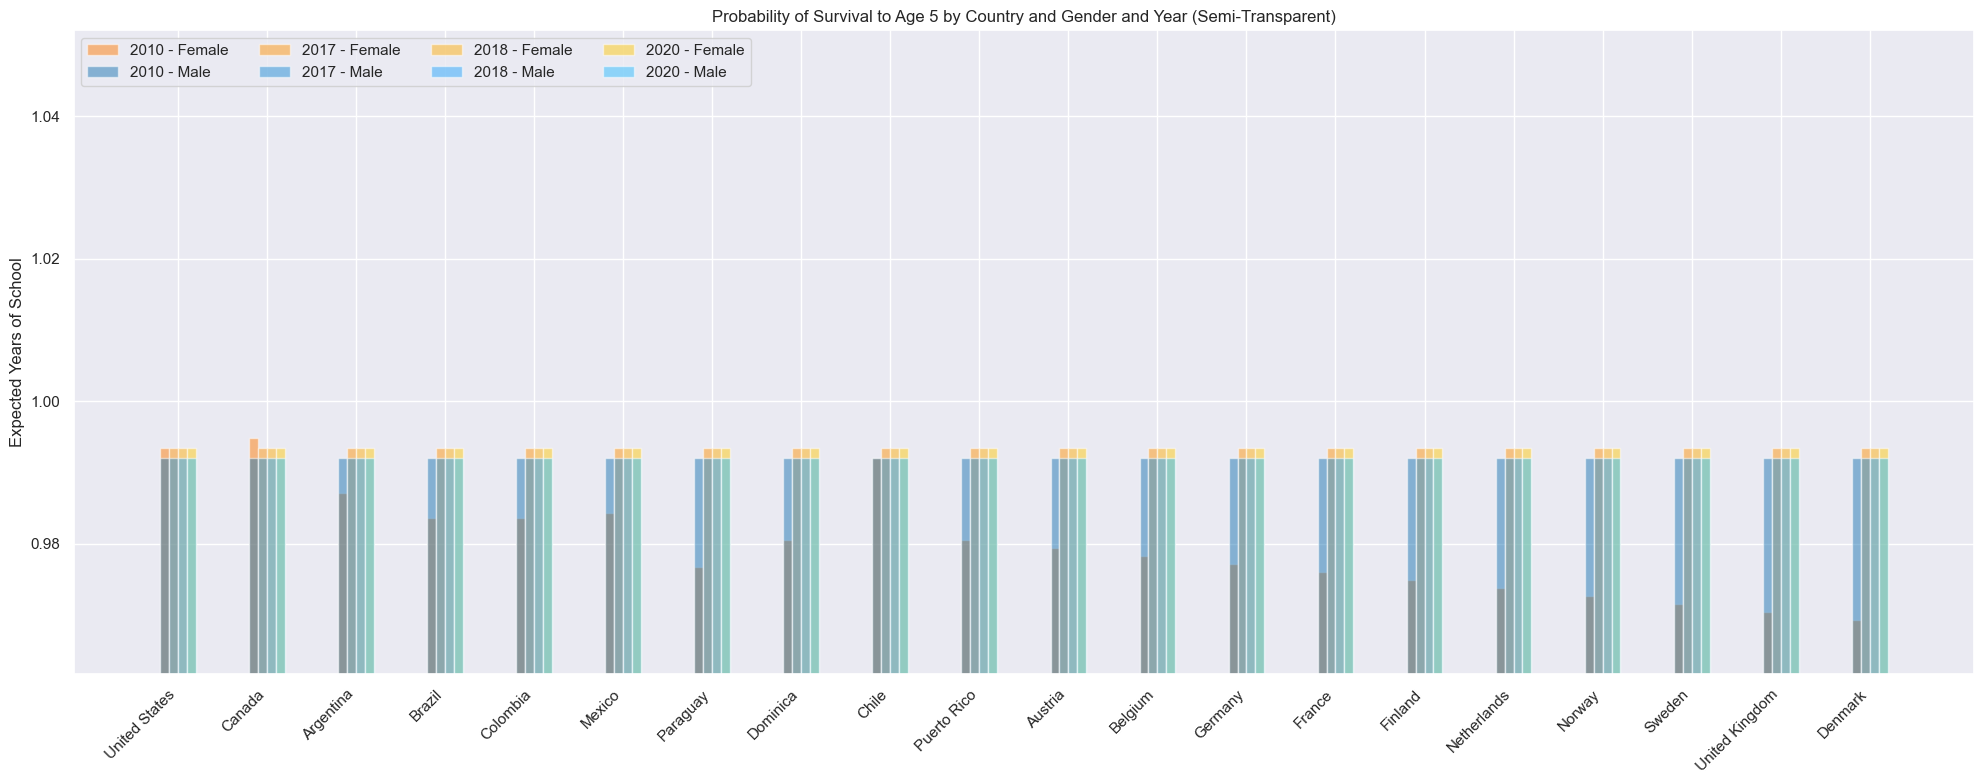

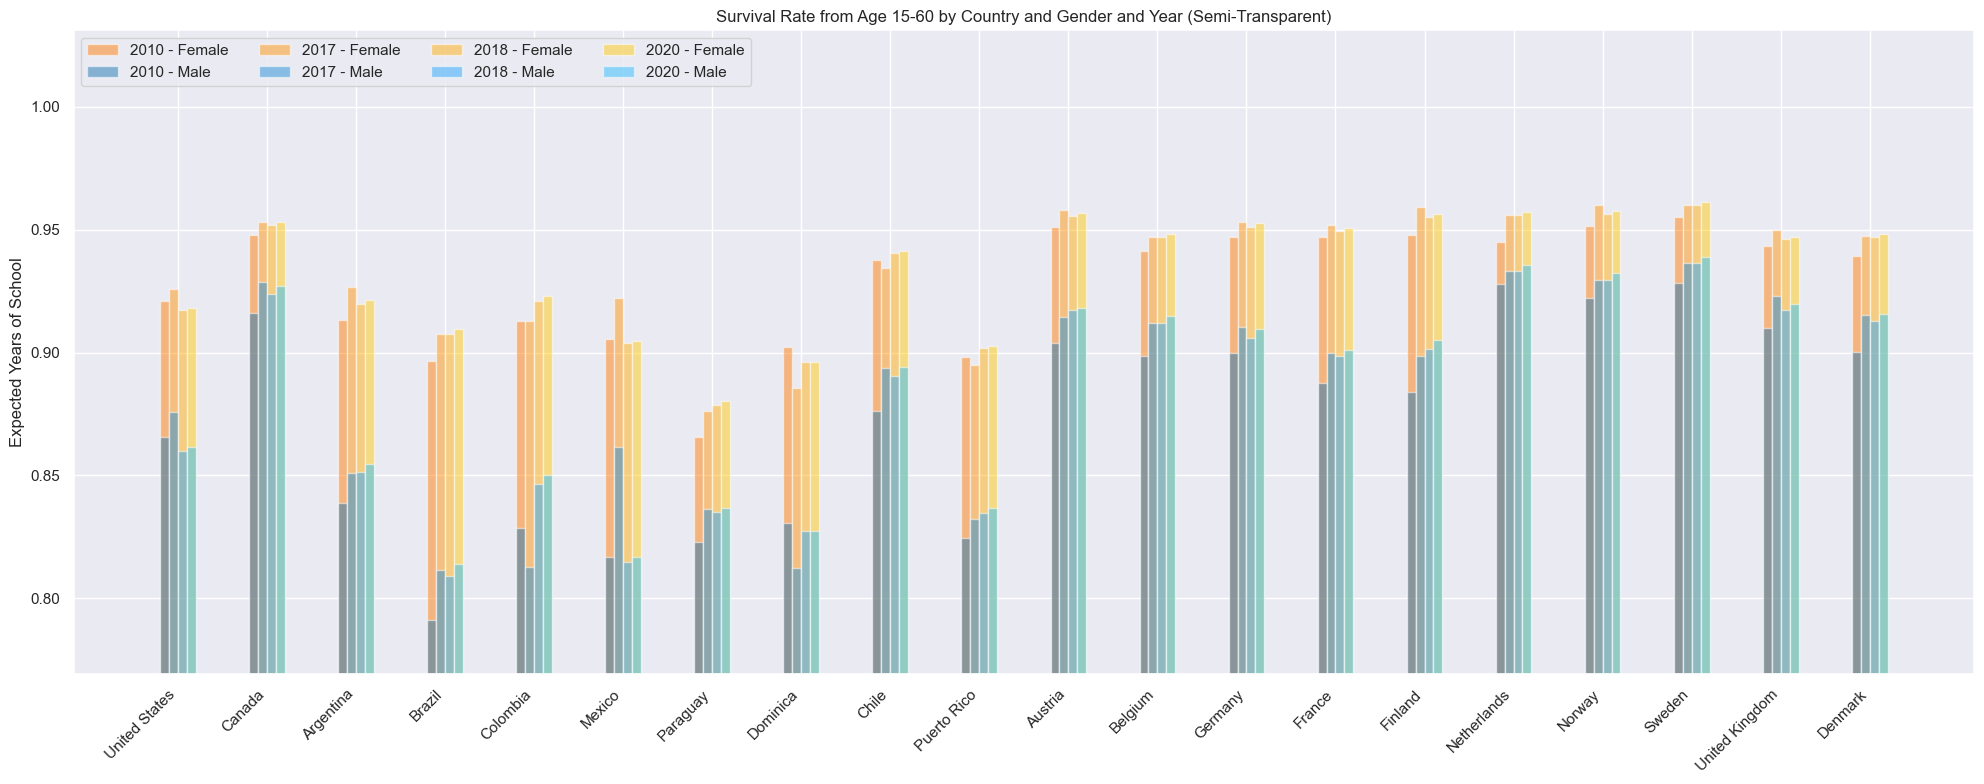

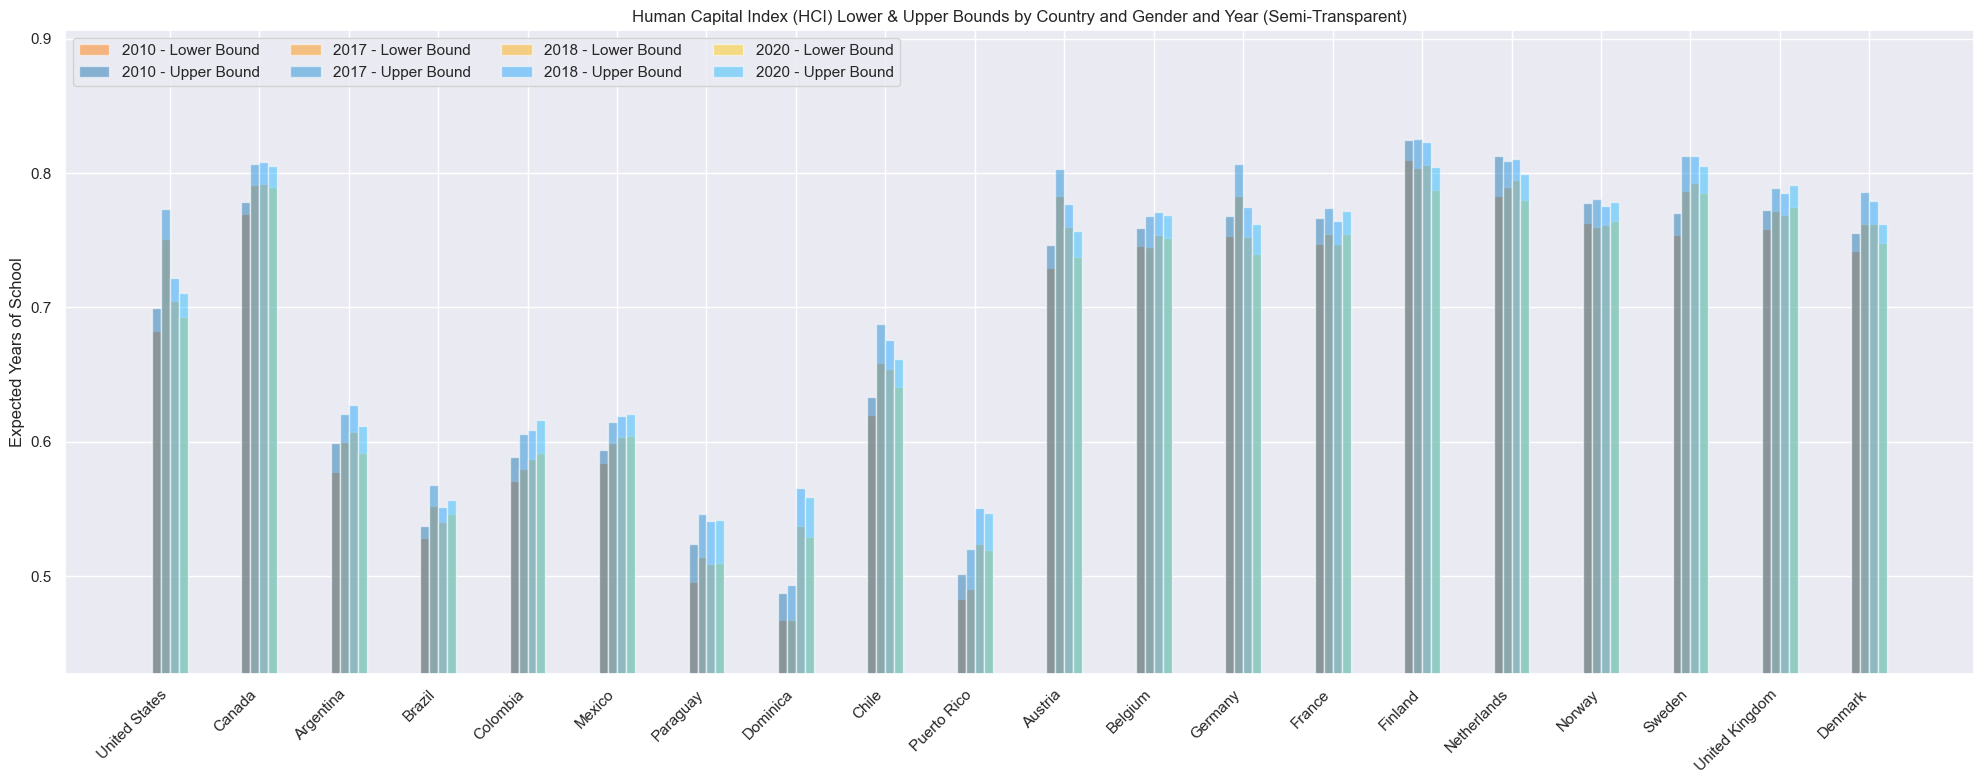

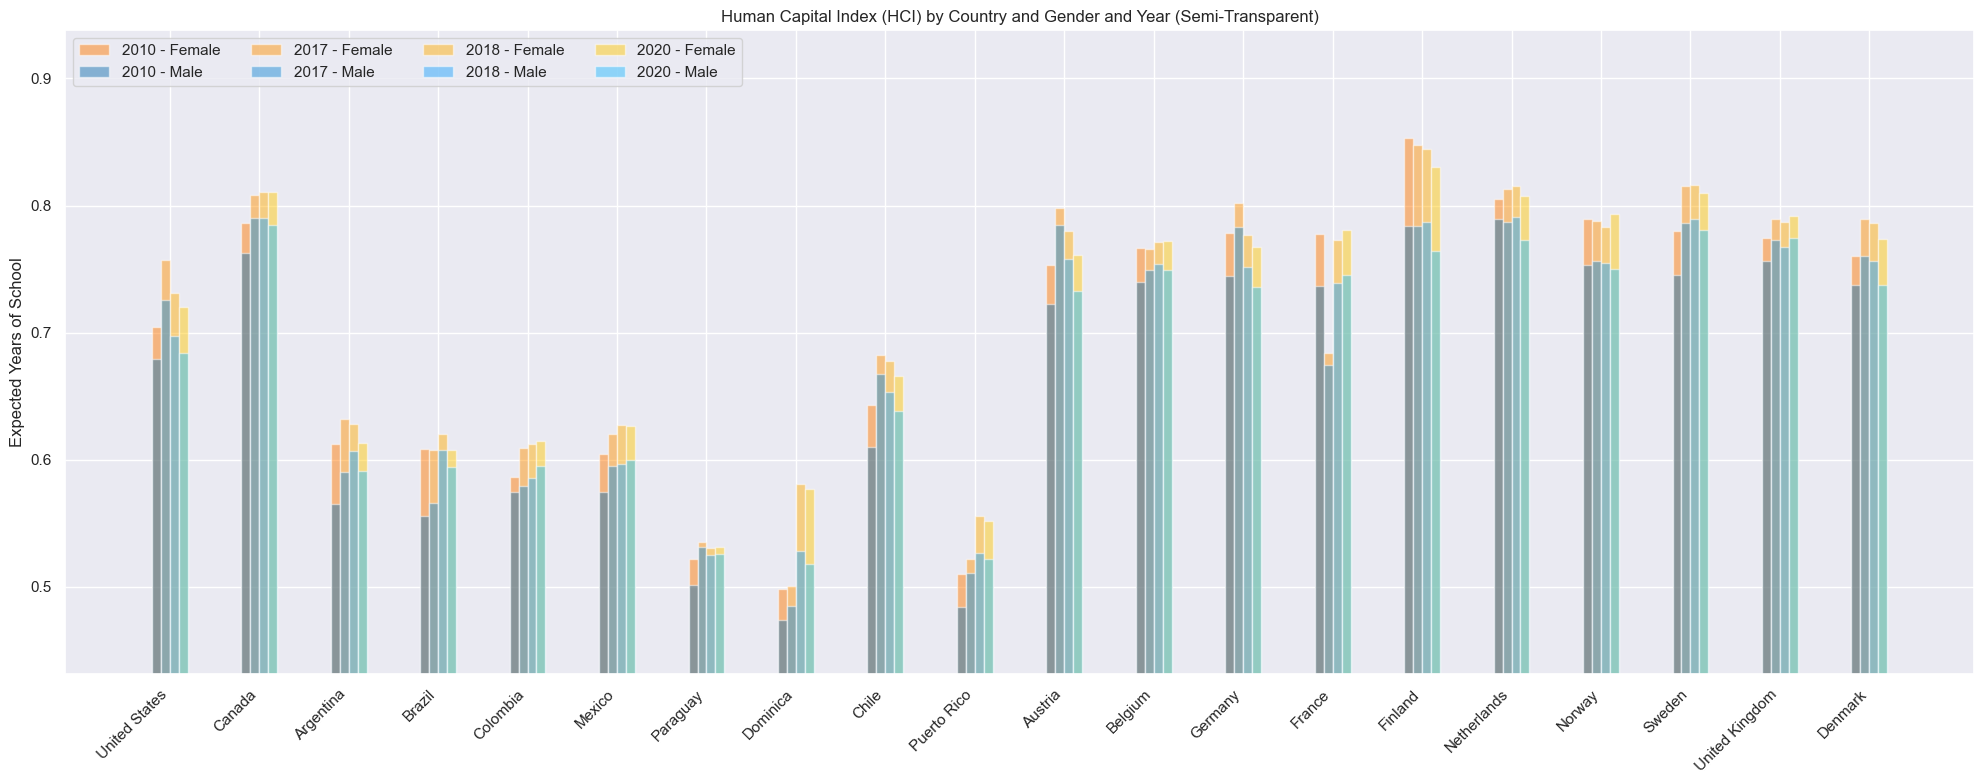

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
sns.set_style("darkgrid")
sns.set()

def adjust_color_brightness(hex_color, factor):
    """
    Lighten or darken a hex color.
    factor < 1: darken
    factor = 1: original
    factor > 1: lighten
    """
    rgb = mcolors.to_rgb(hex_color)  # returns 3 floats (0-1)
    adjusted = tuple(min(1, max(0, c * factor)) for c in rgb)
    return adjusted  # Return as RGB tuple
    
# Load the Excel file
file_path = "P_Data_Extract_From_Human_Capital_Index-one (Edited).xlsm"  # Update this path as needed
df = pd.read_excel(file_path, sheet_name='Data')
    
    # Select the indicator base name
last_indicator = ""
for base_indicator in df["Series Name"].unique():
    years = ["2010", "2017", "2018", "2020"]
    genders = ["Female", "Male"]
    
    if(base_indicator=="Human Capital Index (HCI), Female (scale 0-1)"):
        base_indicator = base_indicator.split(',')[0]
        df_filtered = df[df["Series Name"].isin([
            f"{base_indicator}, {gender} (scale 0-1)" for gender in genders
        ])]
    elif(base_indicator=="Human Capital Index (HCI), Lower Bound (scale 0-1)"):
        base_indicator = base_indicator.split(',')[0]
        genders = ["Lower Bound", "Upper Bound"]
        df_filtered = df[df["Series Name"].isin([
            f"{base_indicator}, {gender} (scale 0-1)" for gender in genders
        ])]
    else:
        base_indicator = base_indicator.split(',')[0]
        if(base_indicator==last_indicator or base_indicator=="Human Capital Index (HCI)"):
            continue
        # Filter data for both genders
        df_filtered = df[df["Series Name"].isin([
            f"{base_indicator}, {gender}" for gender in genders
        ])]
        
    last_indicator = base_indicator
    #print(base_indicator)
    
    # Melt the dataframe into long format
    df_long = df_filtered.melt(
        id_vars=["Country Name", "Series Name"],
        value_vars=years,
        var_name="Year",
        value_name="Value"
    )
    min_value = df_long["Value"].min()
    # Extract gender from Series Name
    df_long["Gender"] = df_long["Series Name"].apply(
        lambda x: x.split(", ")[-1].replace(" (scale 0-1)", "")
    )
    df_long.drop("Series Name", axis=1, inplace=True)
    
    
    # Prepare plotting
    countries = df_long["Country Name"].unique()
    n_countries = len(countries)
    x = np.arange(n_countries)  # positions for each country
    bar_width = 0.1  # narrow width for gender bars
    
    # Color and offsets
    colors = {genders[0]: "#ff7f0e", genders[1]: "#1f77b4"}
    year_offsets = [-0.15, -0.05, 0.05, 0.15]  # spacing for 4 year positions
    
    # Create figure
    plt.figure(figsize=(20, 8))

    # Plot bars
    for i, year in enumerate(years):
        for gender in ( genders):
            year_gender_data = df_long[(df_long["Year"] == str(year)) & (df_long["Gender"] == gender)]
            year_gender_data = year_gender_data.set_index("Country Name").reindex(countries).reset_index()
            values = year_gender_data["Value"].values
    
            # Calculate position: country + offset for year 
            positions = x + year_offsets[i]
            plt.bar(
                positions,
                values,
                width=bar_width,
                alpha=0.5,
                label=f"{year} - {gender}",#if i == 0 else "",
                color=adjust_color_brightness(colors[gender],1+i/5)
            )
    
    # Axis and legend
    plt.xticks(x, countries, rotation=45, ha="right")
    plt.ylabel("Expected Years of School")
    if(genders[0] == "Lower Bound"):
        base_indicator+=" Lower & Upper Bounds"
    plt.title(f'{base_indicator} by Country and Gender and Year (Semi-Transparent)')
    xmin, xmax, ymin, ymax = plt.axis()
    #print(ymin, min_value, ymax)
    #min_value = ymin if min_value!=min_value else min_value
    plt.axis([xmin, xmax, min_value-(ymax-min_value)/10, ymax+(ymax-min_value)/10])
    plt.legend(loc="upper left", ncols=4)
    plt.tight_layout()
    plt.grid(True, axis='y')
    #print(df_long["Gender"].to_string())
    plt.show()
